# Sensitivity Analysis of template project

In [ ]:
from uq_physicell.database.ma_db import load_output
from uq_physicell.model_analysis.utils import calculate_qoi_statistics

db_file = 'Simulations.db'
qoi_funcs = {
    'live_cell_count': lambda df: len( df[ df['dead'] == False ]),
    'dead_cell_count': lambda df: len( df[ df['dead'] == True ]),
    'sum_dead_cell_count': lambda mcds_ts: sum(map(lambda mcds: len(mcds.get_cell_df()[mcds.get_cell_df()['dead'] == True]), mcds_ts))     
}
# Load QoIs structure from db (This does NOT load the entire data to avoid out of memory error)
df_qois_data = load_output(db_file, load_data=False)
# Calculate the QoIs based on the qoi_funcs define (retunr summary based on mean across replicates and relative Monte Carlo standard error: sigma/[mean*sqrt(num_replicates)])
df_summary_qois, df_relative_mcse = calculate_qoi_statistics(df_qois_data, qoi_funcs, db_file_path = db_file)
display(df_summary_qois)

All samples in Samples table have corresponding entries in Output table.
Calculating QoIs from mcds list...
Number of replicates: 5


,time_0,live_cell_count_0,dead_cell_count_0,time_1,live_cell_count_1,dead_cell_count_1,time_2,live_cell_count_2,dead_cell_count_2,time_3,...,time_28,live_cell_count_28,dead_cell_count_28,time_29,live_cell_count_29,dead_cell_count_29,time_30,live_cell_count_30,dead_cell_count_30,sum_dead_cell_count_30
SampleID,,,,,,,,,,,,,,,,,,,,,
0,0.0,511.0,0.0,240.0,582.6,6.8,480.0,632.4,13.2,720.0,...,6720.0,2055.0,58.0,6960.0,2127.2,61.6,7200.0,2197.0,66.6,1107.2
1,0.0,511.0,0.0,240.0,574.8,10.6,480.0,616.6,19.4,720.0,...,6720.0,1835.4,54.4,6960.0,1902.6,54.6,7200.0,1958.0,54.8,1021.0
2,0.0,511.0,0.0,240.0,585.2,5.4,480.0,636.6,11.4,720.0,...,6720.0,2115.6,42.6,6960.0,2188.8,46.6,7200.0,2261.6,48.0,833.4
3,0.0,511.0,0.0,240.0,585.6,4.8,480.0,631.2,11.4,720.0,...,6720.0,2090.2,46.4,6960.0,2169.0,45.2,7200.0,2242.4,45.0,817.2
4,0.0,511.0,0.0,240.0,575.4,7.4,480.0,622.4,16.2,720.0,...,6720.0,1852.6,52.6,6960.0,1918.4,56.2,7200.0,1979.8,56.4,1054.0
5,0.0,511.0,0.0,240.0,580.8,4.4,480.0,619.2,11.4,720.0,...,6720.0,1915.0,38.4,6960.0,1981.4,41.0,7200.0,2040.8,44.8,741.4
6,0.0,511.0,0.0,240.0,586.0,5.2,480.0,629.4,12.8,720.0,...,6720.0,2012.2,50.2,6960.0,2086.2,53.2,7200.0,2164.2,49.4,891.2
7,0.0,511.0,0.0,240.0,592.4,5.0,480.0,637.4,13.2,720.0,...,6720.0,2227.6,50.4,6960.0,2312.2,53.0,7200.0,2400.2,55.4,925.4
8,0.0,511.0,0.0,240.0,586.4,6.8,480.0,625.8,14.6,720.0,...,6720.0,1976.4,53.4,6960.0,2048.0,54.4,7200.0,2113.8,56.0,1010.4


## Plot the summary stats and relative Monte Carlo Standard Error (MCSE)

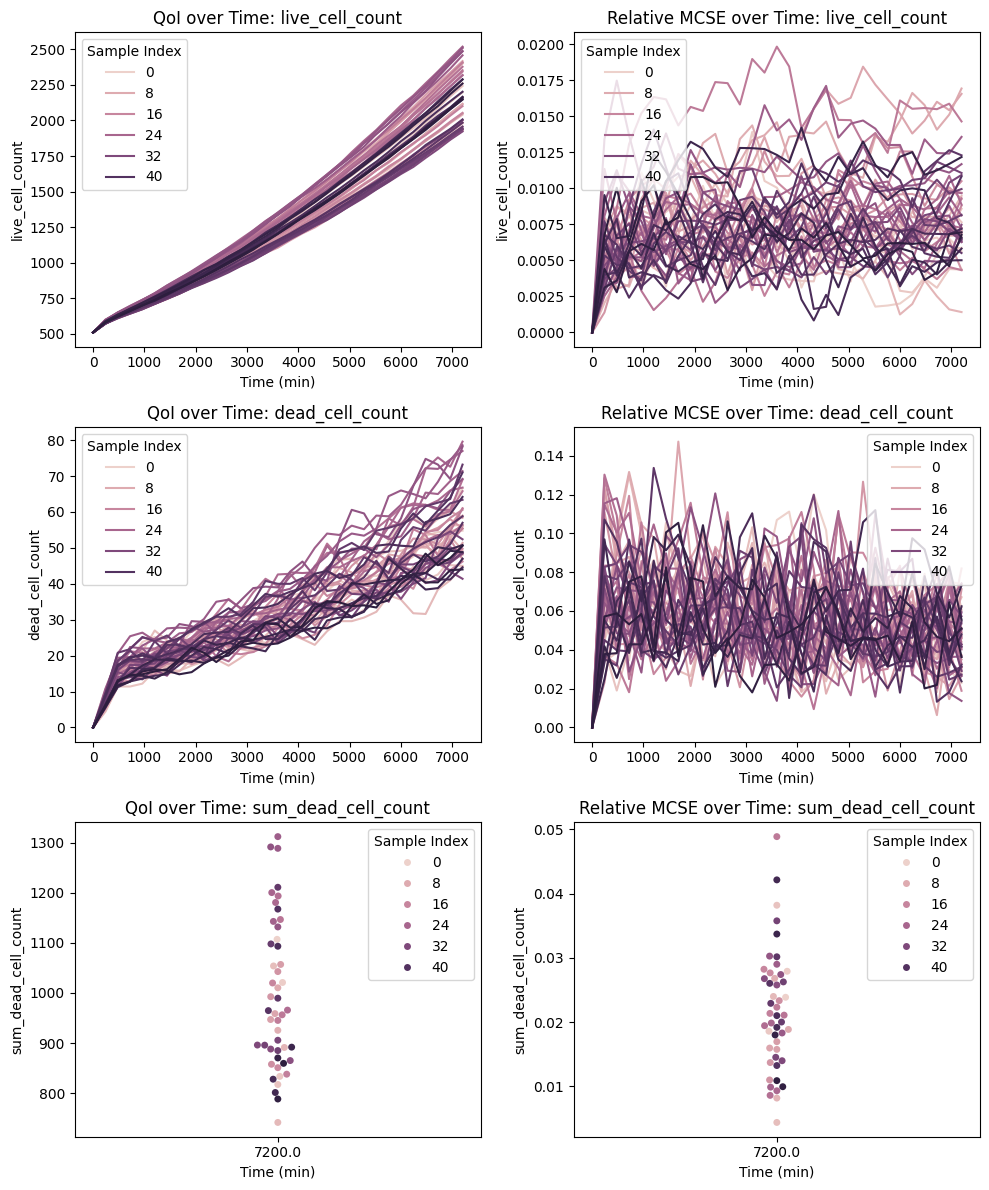

In [2]:
import matplotlib.pyplot as plt
from uq_physicell.gui.utils import plot_qoi_over_time

fig, axes = plt.subplots(len(qoi_funcs.keys()), 2, figsize=(10, 4*len(qoi_funcs.keys())))
for ax_id, qoi_name in enumerate(qoi_funcs.keys()):
     # Plot QoI time series
    plot_qoi_over_time(df_summary_qois, qoi_name, axes[ax_id,0])
    axes[ax_id,0].set_title(f"QoI over Time: {qoi_name}")
    # Plot mcse
    plot_qoi_over_time(df_relative_mcse, qoi_name, axes[ax_id,1])
    axes[ax_id,1].set_title(f"Relative MCSE over Time: {qoi_name}")

# Ensure proper layout and save the figure
plt.tight_layout()  # This will automatically adjust spacing to prevent overlaps
plt.savefig('QoI_TimeSeries_and_MCSE.svg', format='svg')

## Sensitivity Analysis from `cell_cycle_entry` and `apoptosis_rate` relative to population of live and dead cells.

Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 0.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 240.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 480.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 720.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 960.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 1200.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 1440.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 1680.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 1920.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 2160.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 2400.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 2640.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 2880.0
Runnin

/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/SALib/analyze/sobol.py:141: RuntimeWarning: invalid value encountered in divide
  Y = (Y - Y.mean()) / Y.std()


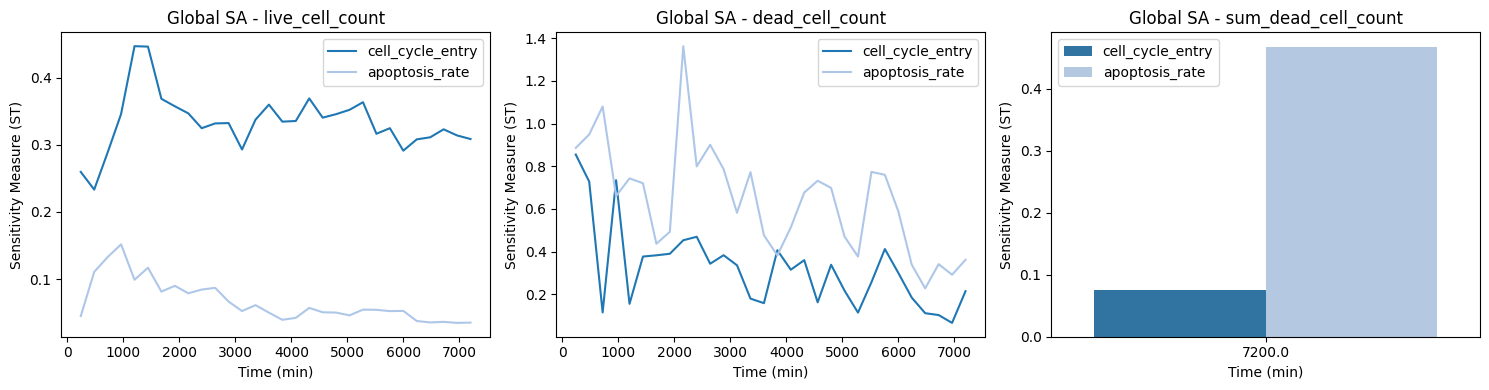

In [3]:
from uq_physicell.gui.utils import get_global_SA_parameters, plot_global_sa_results
from uq_physicell.model_analysis import run_global_sa

sa_method = "Sobol Sensitivity Analysis"
global_SA_parameters = get_global_SA_parameters(db_file)
sa_results, qoi_time_values = run_global_sa(global_SA_parameters, sa_method, qoi_funcs, df_summary_qois)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax_id, qoi_name in enumerate(qoi_funcs.keys()):
    plot_global_sa_results(global_SA_parameters, sa_method, qoi_time_values, sa_results, qoi_name, 'ST' , axes[ax_id], parameter_order=['cell_cycle_entry', 'apoptosis_rate'])
    axes[ax_id].set_title(f'Global SA - {qoi_name}')
    axes[ax_id].legend(loc='best')
plt.tight_layout() # This will automatically adjust spacing to prevent overlaps
plt.savefig('Global_SA_Results.svg', format='svg')

## Plot snapshots of some samples

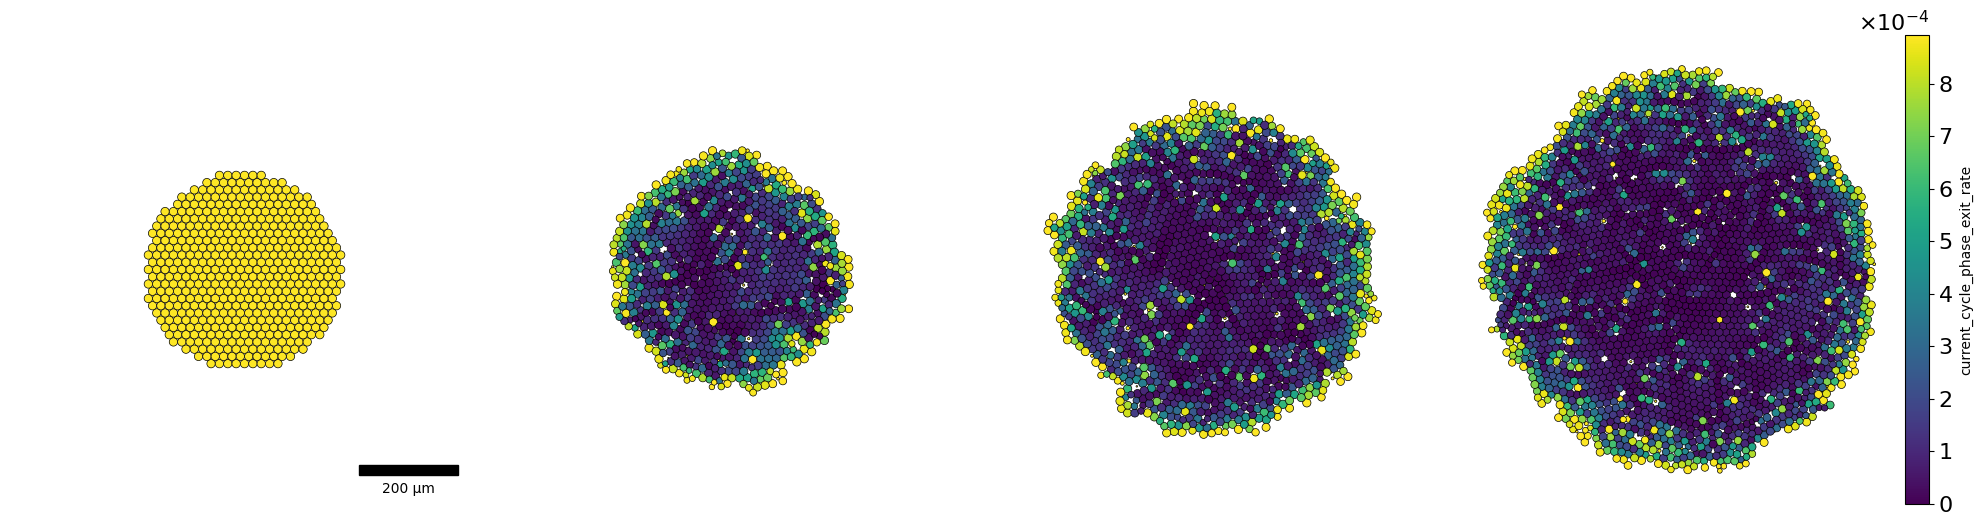

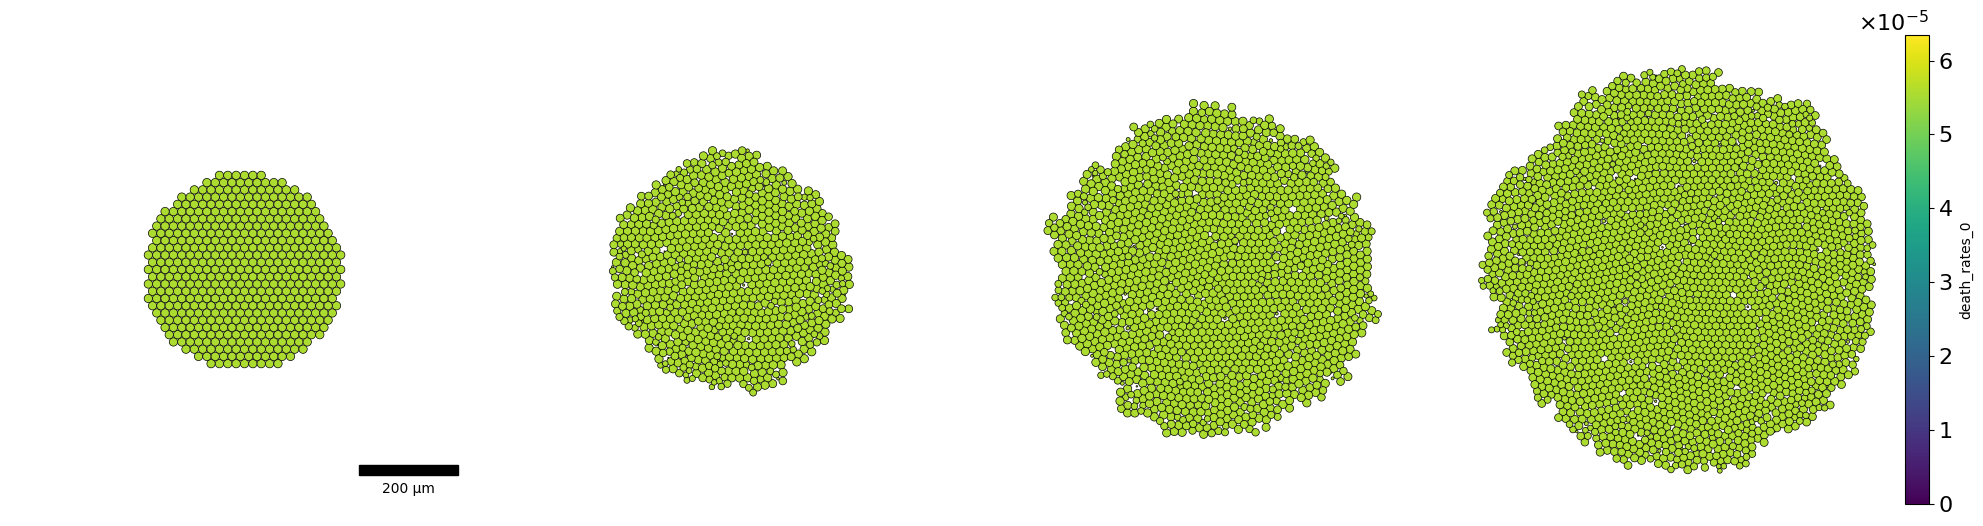

In [4]:
from uq_physicell.database.ma_db import load_output
from uq_physicell.gui.utils import plot_cells_2D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

def plot_snapshots(sample_id, replicate_id, feature, min_value=0, max_value=1):
    df_qois_data_selected = load_output(db_file, sample_ids=[int(sample_id)], replicate_ids=[replicate_id], load_data=True)
    mcds_ts = df_qois_data_selected[df_qois_data_selected['SampleID'] == sample_id].iloc[0]['Data']
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
    ax_id = 0
    last_collection = None
    for i, mcds in enumerate(mcds_ts):
        if mcds.get_time() in [0,1440,4320,7200]: # Plot at specific time points
            df_cell = mcds.get_cell_df()
            last_collection = plot_cells_2D(df_cell, ax=axes[ax_id], scale_bar=True if (ax_id==0) else False, feature=feature, cmap='viridis', vmin=min_value, vmax=max_value)
            ax_id += 1
    cbar = fig.colorbar(last_collection, ax=axes[-1], fraction=0.05, pad=0.02)
    # Configure the formatter to use scientific notation
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2)) # Adjusts when sci-notation kicks in
    cbar.ax.tick_params(labelsize=16)               # tick labels
    cbar.ax.yaxis.get_offset_text().set_size(16)    # scientific notation text (e.g., ×10⁻³)
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label(feature)
    plt.tight_layout()
    plt.savefig(f'snapshot_{feature}_sample{sample_id}_replicate{replicate_id}.svg', format='svg')

plot_snapshots(df_summary_qois[df_summary_qois.columns[df_summary_qois.columns.str.startswith('live_cell_count')]].sum(axis=1).idxmax(), replicate_id=0, feature='current_cycle_phase_exit_rate', max_value=1/pd.DataFrame(global_SA_parameters['samples']).T.min()['cell_cycle_entry'])
plot_snapshots(df_summary_qois[df_summary_qois.columns[df_summary_qois.columns.str.startswith('live_cell_count')]].sum(axis=1).idxmax(), replicate_id=0, feature='death_rates_0', max_value=pd.DataFrame(global_SA_parameters['samples']).T.max()['apoptosis_rate'])
# plot_snapshots(df_summary_qois[df_summary_qois.columns[df_summary_qois.columns.str.startswith('live_cell_count')]].sum(axis=1).idxmin(), replicate_id=0, feature='current_cycle_phase_exit_rate', max_value=1/pd.DataFrame(global_SA_parameters['samples']).T.min()['cell_cycle_entry'])
# plot_snapshots(df_summary_qois[df_summary_qois.columns[df_summary_qois.columns.str.startswith('sum_dead_cell_count')]].idxmax().values[0], replicate_id=0, feature='death_rates_0', max_value=pd.DataFrame(global_SA_parameters['samples']).T.max()['apoptosis_rate'])
# plot_snapshots(df_summary_qois[df_summary_qois.columns[df_summary_qois.columns.str.startswith('sum_dead_cell_count')]].idxmin().values[0], replicate_id=0, feature='death_rates_0', max_value=pd.DataFrame(global_SA_parameters['samples']).T.max()['apoptosis_rate'])